# 💎 Prédiction du Prix des Diamants
## Notebook 1 : Analyse Exploratoire des Données (EDA)
**Auteur :** Hadj Mbarek Arwa  
**Date :** Avril 2026

---
### Objectif de ce notebook
Ce notebook a pour but de **comprendre et explorer** le dataset des diamants avant toute modélisation.
Nous allons répondre aux questions suivantes :
- Quelle est la structure des données ?
- Y a-t-il des valeurs manquantes ou aberrantes ?
- Quelles variables sont les plus corrélées au prix ?

## Étape 0 — Importation des librairies

In [2]:
# ── Librairies de base ──────────────────────────────────────────────────────
import pandas as pd          # Manipulation des données
import numpy as np           # Calculs numériques

# ── Librairies de visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuration de l'affichage ────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')  # Style propre et professionnel
sns.set_palette('husl')                  # Palette de couleurs
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes

# Ignorer les avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

print('Librairies importées avec succès ')

Librairies importées avec succès 


## Étape 1 — Chargement des données

In [3]:
# Chargement du fichier CSV
# Assurez-vous que le fichier diamond.csv est dans le dossier ../data/
df = pd.read_csv(r'C:\Users\TUF\Downloads\diamond_project\diamond_project\data\diamonds.csv')

print(f' Dataset chargé avec succès !')
print(f'   → Nombre de lignes   : {df.shape[0]:,}')
print(f'   → Nombre de colonnes : {df.shape[1]}')

 Dataset chargé avec succès !
   → Nombre de lignes   : 53,940
   → Nombre de colonnes : 11


In [4]:
# Aperçu des 5 premières lignes
print(' Aperçu des premières lignes :')
df.head()

 Aperçu des premières lignes :


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
# Supprimer la colonne d'index si elle existe (souvent nommée 'Unnamed: 0')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print('Colonne index supprimée.')

print(f'Colonnes disponibles : {list(df.columns)}')

Colonne index supprimée.
Colonnes disponibles : ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


## Étape 2 — Exploration de la Structure des Données

In [6]:
# Informations générales sur le dataset (types de données, valeurs non-nulles)
print('Informations générales :')
df.info()

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [7]:
# Statistiques descriptives pour les variables numériques
print('Statistiques descriptives (variables numériques) :')
df.describe().round(2)

Statistiques descriptives (variables numériques) :


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


In [8]:
# Statistiques pour les variables catégorielles
cat_cols = ['cut', 'color', 'clarity']
print('Valeurs uniques par variable catégorielle :')
for col in cat_cols:
    print(f'\n  → {col} : {df[col].unique()}')
    print(f'     Fréquences :')
    print(df[col].value_counts().to_string())

Valeurs uniques par variable catégorielle :

  → cut : ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
     Fréquences :
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610

  → color : ['E' 'I' 'J' 'H' 'F' 'G' 'D']
     Fréquences :
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808

  → clarity : ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']
     Fréquences :
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741


## Étape 3 — Vérification des Valeurs Manquantes

In [9]:
# Compter les valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})

print('Analyse des valeurs manquantes :')
print(missing_df)

if missing.sum() == 0:
    print('\nAucune valeur manquante ! Le dataset est propre.')
else:
    print(f'\nTotal valeurs manquantes : {missing.sum()}')

Analyse des valeurs manquantes :
         Valeurs manquantes  Pourcentage (%)
carat                     0              0.0
cut                       0              0.0
color                     0              0.0
clarity                   0              0.0
depth                     0              0.0
table                     0              0.0
price                     0              0.0
x                         0              0.0
y                         0              0.0
z                         0              0.0

Aucune valeur manquante ! Le dataset est propre.


## Étape 4 — Détection des Valeurs Aberrantes (Outliers)

In [10]:
# Les dimensions x, y, z ne peuvent pas être égales à 0 pour un vrai diamant
print('Valeurs aberrantes dans les dimensions (x, y, z = 0) :')
outliers_zero = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f'   → {len(outliers_zero)} ligne(s) avec une dimension = 0')

# Valeurs extrêmes dans y et z (erreurs de saisie)
print(f"\n   → Valeur max de y : {df['y'].max()} mm  (suspecte si > 30mm)")
print(f"   → Valeur max de z : {df['z'].max()} mm  (suspecte si > 30mm)")
print(f"\n   → Lignes avec y > 30mm : {(df['y'] > 30).sum()}")
print(f"   → Lignes avec z > 30mm : {(df['z'] > 30).sum()}")

Valeurs aberrantes dans les dimensions (x, y, z = 0) :
   → 20 ligne(s) avec une dimension = 0

   → Valeur max de y : 58.9 mm  (suspecte si > 30mm)
   → Valeur max de z : 31.8 mm  (suspecte si > 30mm)

   → Lignes avec y > 30mm : 2
   → Lignes avec z > 30mm : 1


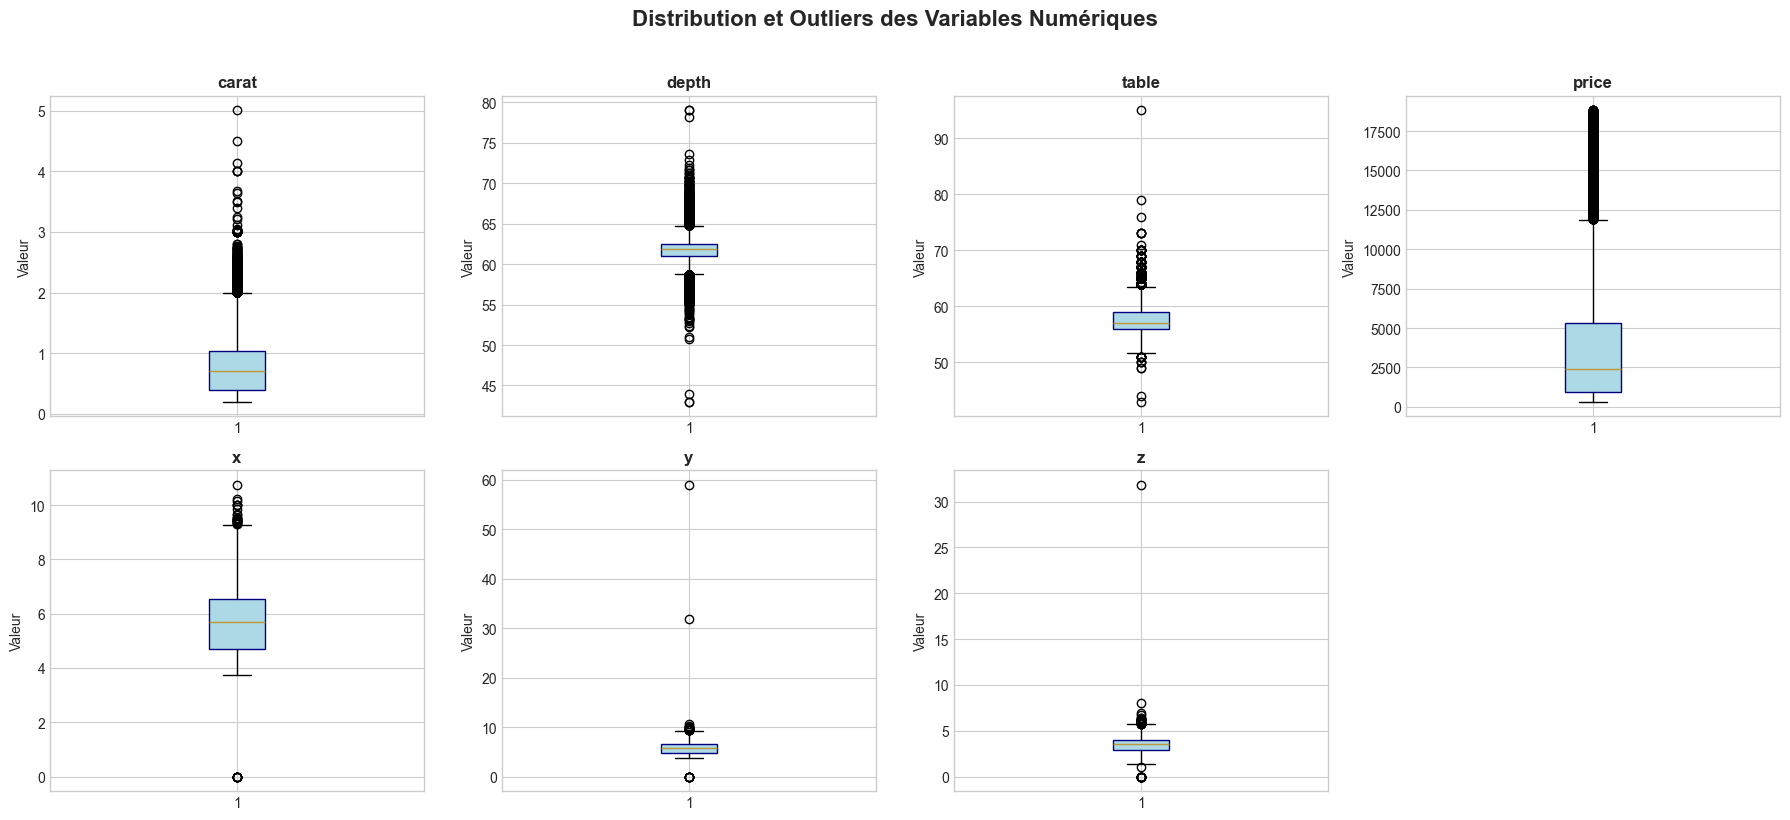

Graphique sauvegardé.


In [11]:
# Visualisation des outliers avec des boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution et Outliers des Variables Numériques', 
             fontsize=16, fontweight='bold', y=1.02)

num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for idx, col in enumerate(num_cols):
    row, col_idx = divmod(idx, 4)
    axes[row, col_idx].boxplot(df[col], patch_artist=True,
                               boxprops=dict(facecolor='lightblue', color='navy'))
    axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Valeur')

# Masquer le dernier graphique vide
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.savefig('../data/boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé.')

## Étape 5 — Distribution des Variables

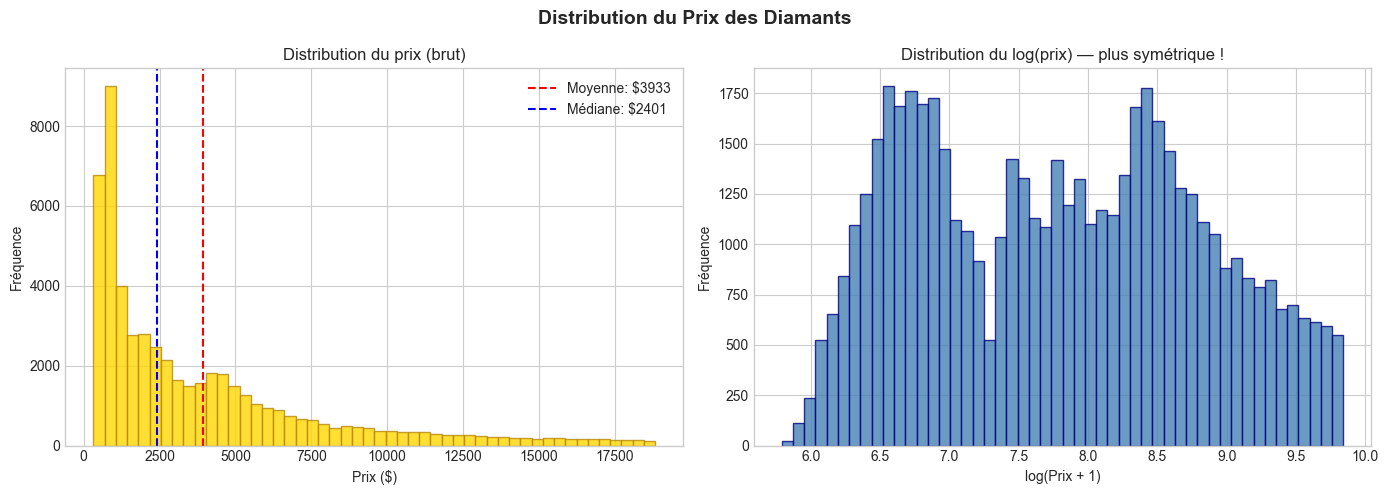

Observation : La distribution du prix est asymétrique à droite (right-skewed).
   → Une transformation logarithmique la rend plus normale.


In [12]:
# Distribution de la variable cible : PRICE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution du Prix des Diamants', fontsize=14, fontweight='bold')

# Histogramme du prix
axes[0].hist(df['price'], bins=50, color='gold', edgecolor='darkgoldenrod', alpha=0.8)
axes[0].set_title('Distribution du prix (brut)')
axes[0].set_xlabel('Prix ($)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Moyenne: ${df["price"].mean():.0f}')
axes[0].axvline(df['price'].median(), color='blue', linestyle='--', label=f'Médiane: ${df["price"].median():.0f}')
axes[0].legend()

# Distribution du log du prix (pour voir si une transformation log améliore la normalité)
axes[1].hist(np.log1p(df['price']), bins=50, color='steelblue', edgecolor='navy', alpha=0.8)
axes[1].set_title('Distribution du log(prix) — plus symétrique !')
axes[1].set_xlabel('log(Prix + 1)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../data/distribution_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation : La distribution du prix est asymétrique à droite (right-skewed).')
print('   → Une transformation logarithmique la rend plus normale.')

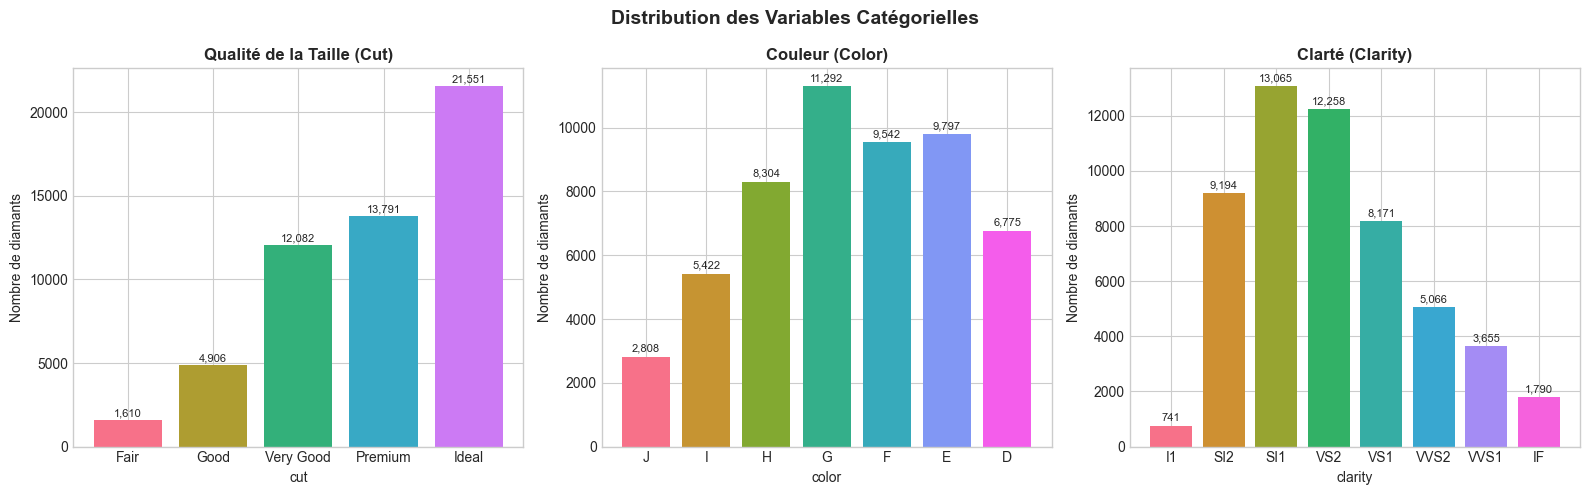

In [13]:
# Distribution des variables catégorielles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution des Variables Catégorielles', fontsize=14, fontweight='bold')

# Ordre logique pour chaque variable ordinale
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

for ax, col, order, title in zip(
    axes,
    ['cut', 'color', 'clarity'],
    [cut_order, color_order, clarity_order],
    ['Qualité de la Taille (Cut)', 'Couleur (Color)', 'Clarté (Clarity)']
):
    counts = df[col].value_counts().reindex(order)
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('husl', len(order)))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre de diamants')
    # Ajouter les valeurs sur les barres
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/distribution_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## Étape 6 — Analyse des Corrélations

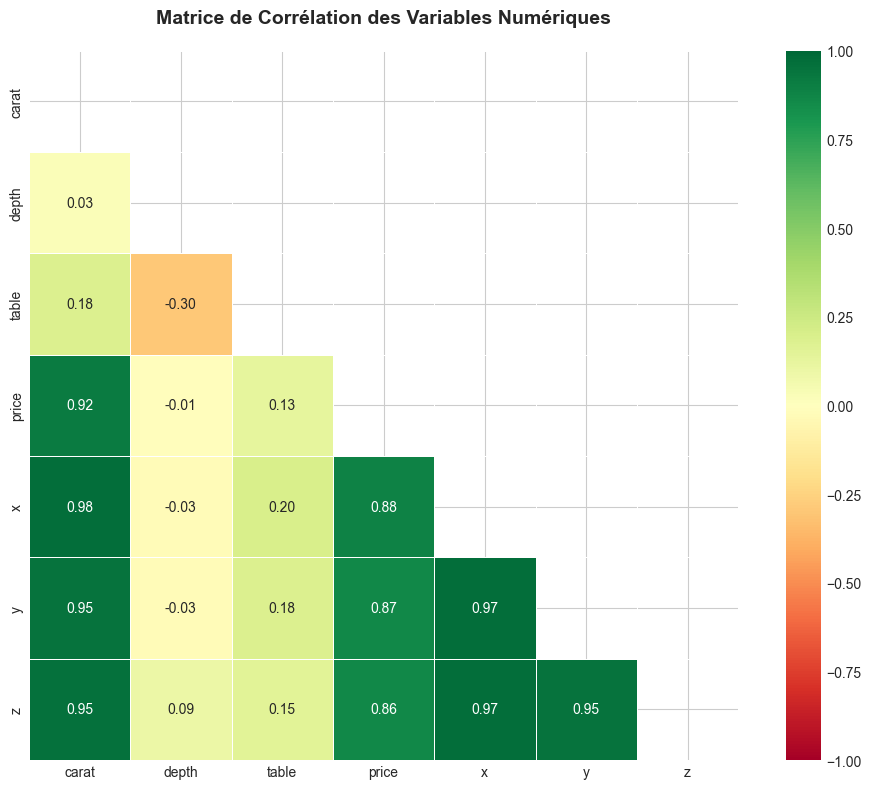

Corrélations avec le PRIX :
   carat    : +0.922  ██████████████████
   x        : +0.884  █████████████████
   y        : +0.865  █████████████████
   z        : +0.861  █████████████████
   table    : +0.127  ██
   depth    : -0.011  


In [14]:
# Matrice de corrélation des variables numériques
num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masquer le triangle supérieur

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Afficher les valeurs
    fmt='.2f',            # 2 décimales
    cmap='RdYlGn',        # Rouge (négatif) → Vert (positif)
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matrice de Corrélation des Variables Numériques', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Corrélations avec le PRIX :')
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
for var, val in price_corr.items():
    bar = '█' * int(abs(val) * 20)
    print(f'   {var:8s} : {val:+.3f}  {bar}')

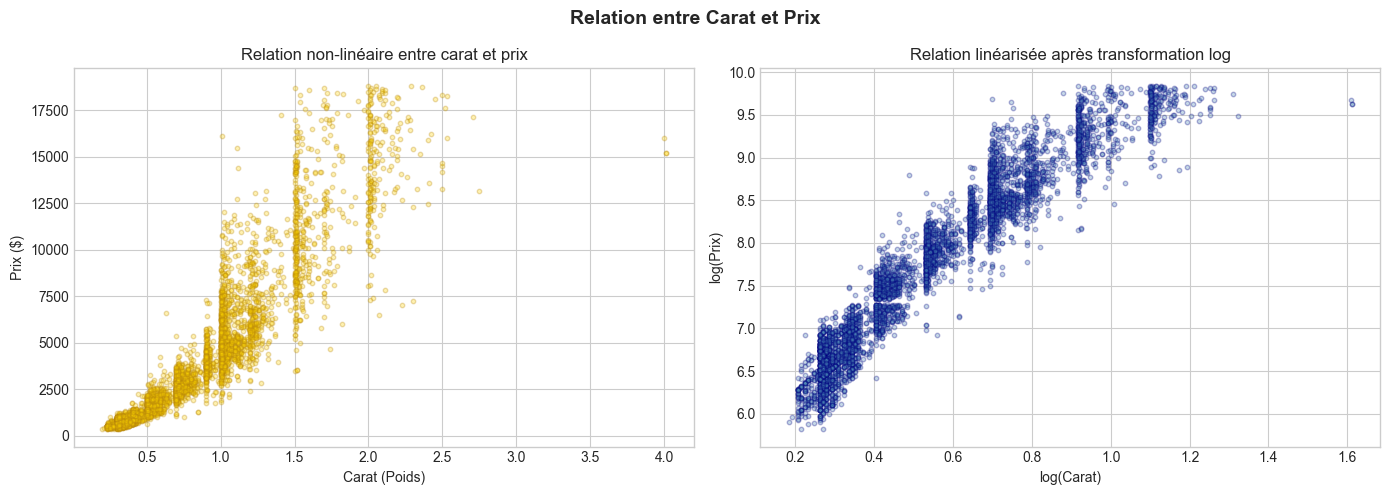

La relation entre carat et prix devient linéaire après transformation log.


In [15]:
# Relation entre CARAT et PRIX (la corrélation la plus forte)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relation entre Carat et Prix', fontsize=14, fontweight='bold')

# Scatter plot (on prend un échantillon pour la lisibilité)
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample['carat'], sample['price'], alpha=0.3, color='gold', edgecolors='darkgoldenrod', s=10)
axes[0].set_xlabel('Carat (Poids)')
axes[0].set_ylabel('Prix ($)')
axes[0].set_title('Relation non-linéaire entre carat et prix')

# Avec log-transformation
axes[1].scatter(np.log1p(sample['carat']), np.log1p(sample['price']), 
                alpha=0.3, color='steelblue', edgecolors='navy', s=10)
axes[1].set_xlabel('log(Carat)')
axes[1].set_ylabel('log(Prix)')
axes[1].set_title('Relation linéarisée après transformation log')

plt.tight_layout()
plt.savefig('../data/carat_vs_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print('La relation entre carat et prix devient linéaire après transformation log.')

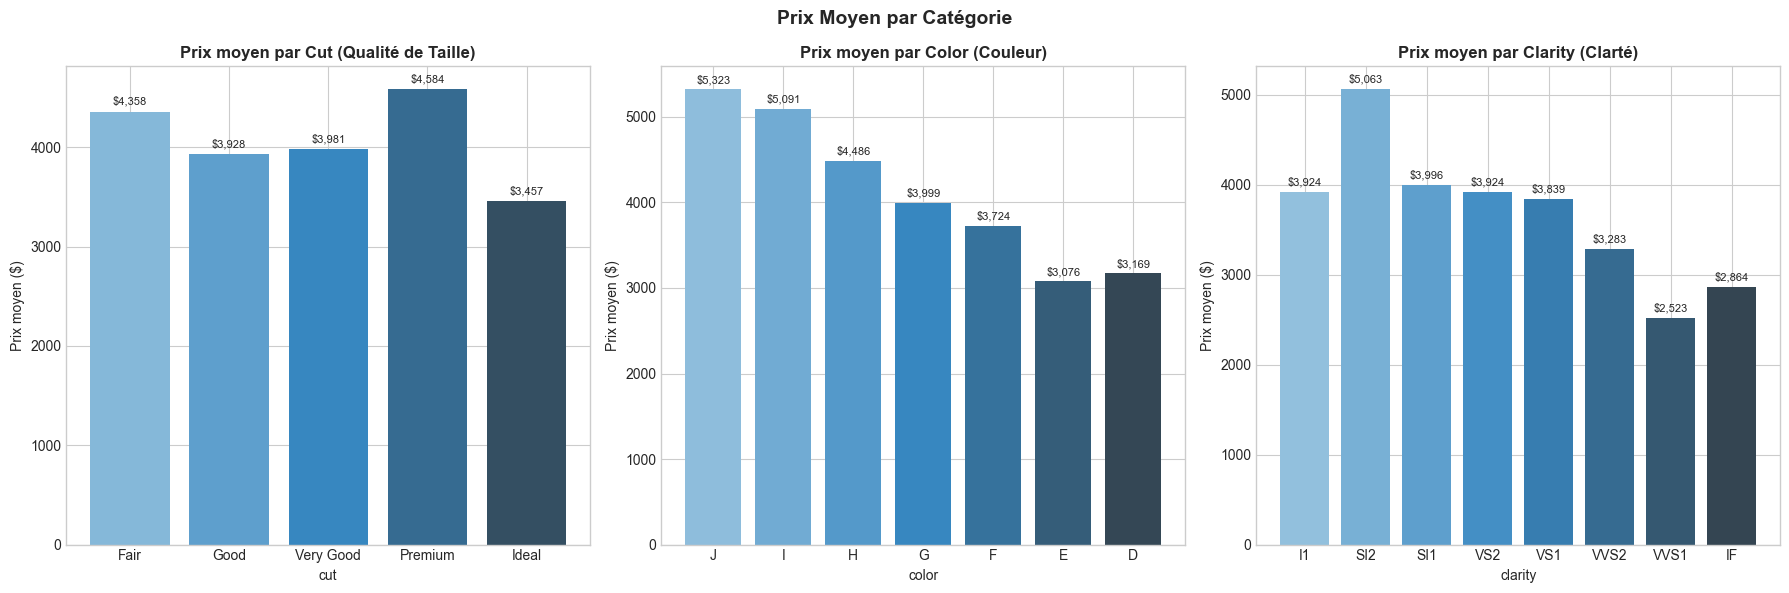

In [16]:
# Prix moyen par catégorie
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Prix Moyen par Catégorie', fontsize=14, fontweight='bold')

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

for ax, col, order, title in zip(
    axes,
    ['cut', 'color', 'clarity'],
    [cut_order, color_order, clarity_order],
    ['Cut (Qualité de Taille)', 'Color (Couleur)', 'Clarity (Clarté)']
):
    mean_price = df.groupby(col)['price'].mean().reindex(order)
    bars = ax.bar(mean_price.index, mean_price.values, 
                  color=sns.color_palette('Blues_d', len(order)))
    ax.set_title(f'Prix moyen par {title}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Prix moyen ($)')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/prix_par_categorie.png', dpi=150, bbox_inches='tight')
plt.show()